# Multiclass Classification of Medical Images Using Dense Neural Networks

## A Systematic Approach and Investigation of Model Capacity and Dropout 

### Aim of Study 
This study applies the universal deep learning workflow outlined in Deep Learning with Python(Chollet) to a multiclass medical image classification task. The objective is to develop and systematically evaluate neural network architectures capable of classifying medical images into six anatomical and modality categories, namely, Abdomen CT, Breast MRI, Chest X-ray(CXR), Chest CT, Hand(X-ray), and Head CT.
The scope of the investigation is deliberately constrained to Sequential models which are composed of Dense and Dropout  layers, which allows for a controlled analysis of architectural depth and influence model behaviour without the confusing effects of convolutional feature extraction. Within this constrained space, needed attention is given to model capacity(effect of changing the number and size of hidden layers), overfitting(identified through divergence between training and validation performance), generalisation(assessed via held-out test performance), and the regularising effect of dropoUt on mitigating overfitting and improved generalisation.



### 1. Problem Definition
The aim of the study is to develop a neural network capable of sorting medical images into one of six categories: Abdomen CT, Breast MRI, Chest X-ray(CXR), Chest CT, Hand, and Head CT. 
This constitutes a multiclass, single-label classification problem, as each image belongs to exactly one of the six possible classes. The input to the model is a grayscale medical image of dimensions 64 x 64 pixels, and the output is a predicted class label corresponding to one of the six categories.
The investigation is deliberately restricted to Sequential architectures composed of Dense and Dropout layers only. This constraint means the model cannot natively exploit the two-dimensional spatial structure of image data, as Dense layers operate exclusively on flat feature vectors, which is a key limitation that distinguishes this approach from convolutional architectures and is revisited throughout this study.
The central research question is whether a fully connected network can learn discriminate patterns directly from raw pixel intensities to distinguish between the six medical image categories, despite the loss of spacial locality. Model performance is evaluated systematically by varying network capacity and regularisation strength while monitoring training and validation metrics across epochs to characterise overfitting and generalisation behaviour.
#### 1.1 Dataset Description
The dataset comprises 58,954 grayscale medical images distributed across six classes, each image having a resolution of 64 x 64 pixels. The classes span multiple imaging modalities that include CT, MRI, and X-ray which represents distinct anatomical regions or body parts. 
The dataset is relatively well balanced. Five of the classes contain 10,000 images each, while the Breast MRI class contains 8,954 images. The near-uniform distribution reduces the likelihood of the model becoming biased towards any single class due to overrepresentation in the training data.
The class distribution is summarised in Table X below

| Class | Number of Images |
| :--- | :--- |
| Abdomen CT | 10,000|
| Breast MRI | 8,954 |
| Chest X-ray(CXR) | 10,000 |
| Chest CT | 10,000 |
| Hand | 10,000 |
| Head CT| 10,000 |
| Total | 58,954|

#### 1.2. Measure of Success
Having defined the data and preprocessing pipeline, the next step is to establish how model performance will be measured. Classification accuracy will serve as the primary measure of success, as it directly reflects the proportion of images correctly assigned to their tue class. Given the class balance mentioned in Section 1.1, accuracy is considered an appropriate metric, since no single class is heavily underrepresented enough to distort this measure.
To provide context for model performance, accuracy will be compared against a naive random-guessing baseline of approximately 16.7%(1/6, given six balanced classes). Any model developed in this study will need to substantially exceed this baseline to be considered informative.
Both training and validation accuracy will be monitored throughout training to assess learning and generalisation respectively, alongside categorical cross-entropy loss, which is appropriate given the multiclass, single-label nature of the task. Comparing training and validation performance over time will help identify overfitting or underfitting as training progresses. 
A successful model will therefore be one that achieves accuracy well above the random baseline while maintaining comparable performance on the training and validation sets, with minimal divergence between the two. Finally, the best-performing model, selected using validation performance, will be evaluated once on a held-out test set that plays no role in training or model selection, providing an unbiased generalisation to new data.

#### 1.3. Evaluation Protocol 
To assess the models developed in this study, a hold-out validation approach will be adopted. The complete dataset will be partitioned into three subsets, that is, 70% for training which will be used to update the network's weights, 15% for validation, used to monitor performance and compare configurations during experimentation, and 15% for testing, reserved exclusively for final model evaluation.
This split will be performed using stratified sampling, ensuring that each subset preserves  approximately the same class proportions as the full dataset, which is a particularly relevant consideration given the slight underrepresentation of the Breast MRI class noted in Section 1.1. A fixed random seed will be used throughout, ensuring the same three subsets can be reproduced consistently across repeated runs of the experiment. 
The validation set will play a key role during model development, guiding decisions around network capacity, depth, dropout rate, and training duration. The test set, by contrast will be withheld entirely from this process, since repeated evaluation on test data can indirectly influence model design and lead to overly optimistic performance estimates, it will be only used once, that is, to evaluate the final, selected model configuration after all development decisions have been finalised using validation performance alone.






### 2. Data Preparation
Before the images can be used to train a neural network, they must be converted into a suitable numerical format. This section outlines how the image data and corresponding labels will be prepared for modelling. 
Preparation will involve loading the images from their class folders, converting them into numerical arrays, assigning a numerical label to each class, reshaping each image into a one-dimensional vector, and normalising pixel values. The prepared data will then be split into trainig, validation and test sets, following the evaluation protocol outlined in Section 1.3.
No preliminary data visualisation is performed at this stage, as the focus of this experiment is on the deep learning workflow and subsequent model evaluation.

#### 2.1. Importing Required Libraries
Several libraries will be used to support this workflow, namely, NumPy for numerical array operations, Pillow for loading image files, and Scikit-learn for creating the stratified training, validation, and test subsets. TensorFlow and Keras are used later to construct and train the neural networks.



In [1]:
#--- Imports ----
import os
import numpy as np
import pandas as pd


from PIL import Image
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers



In [2]:
#---- Cell reproducibility ----
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

#### 2.2 Loading The Dataset
The dataset is organised into six folders, each corresponding to one class, namely, AbdomenCT, BreastMRI, CXR, ChestCT, Hand, and HeadCT. Each image is loaded as a grayscale and converted into a NumPy array, with a numerical label assigned based on its source folder. At this stage, images retain their original 64 x 64 dimensions and unsigned 8-bit integer pixel values. Reshaping and normalisation are handled separately in the preprocessing stage that follows.


In [3]:
#----------- Dataset Setup ----------------------------
#Path to the dataset directory containing a subfolder for each class
dataset_path = "dataset"

#Class names correspond exactly to dataset's folder names
class_names = [
    "AbdomenCT",
    "BreastMRI",
    "CXR",
    "ChestCT",
    "Hand",
    "HeadCT",
]

#Map each class name to a unique integer label(0-5)
class_to_label = {class_name: label for label, class_name in enumerate(class_names)}

print("Class to label mapping:")
for class_name, label in class_to_label.items():
    print(f"{class_name}: {label}")


Class to label mapping:
AbdomenCT: 0
BreastMRI: 1
CXR: 2
ChestCT: 3
Hand: 4
HeadCT: 5


In [4]:
#----- Image Finding -------------------------
#Collect (file_path, label) pairs for all images in the dataset
image_files = []

for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)
    
    #Only keep valid image files, sorted for a consistent, reproducible order 
    files = sorted(
        file_name
        for file_name in os.listdir(class_path)
        if file_name.lower().endswith((".png", ".jpg", ".jpeg"))
    )
    for file_name in files:
        image_files.append((os.path.join(class_path, file_name), class_name))

print(f"Total images found: {len(image_files)}")

Total images found: 58954


In [5]:
# -------- Image Loading --------
#Pre-allocate arrays for images and labels for efficiency
images = np.empty((len(image_files), 64, 64), dtype=np.uint8)  # Grayscale images of size 64x64
labels = np.empty((len(image_files),), dtype=np.int32)

#Load each image as grayscale, vaidate its dimensions, and store it 
#alongside its corresponding label
for index, (image_path, class_name) in enumerate(image_files):
    with Image.open(image_path) as image:
        image = image.convert("L")  # ensure single channel (grayscale)
        
        if image.size != (64, 64):
            raise ValueError(f"Image {image_path} has invalid dimensions {image.size}. Expected (64, 64).")
        
        images[index] = np.array(image)
        
    labels[index] = class_to_label[class_name]

print(f"Images shape: {images.shape}, Labels shape: {labels.shape}, Image data type: {images.dtype}, Labels data type: {labels.dtype}")

Images shape: (58954, 64, 64), Labels shape: (58954,), Image data type: uint8, Labels data type: int32


In [6]:
#---- Verification that all six classes are present in the dataset ----
unique_labels, class_counts = np.unique(labels, return_counts=True)

print("Class distribution after preprocessing:")
for label, count in zip(unique_labels, class_counts):
    print(f"  {class_names[label]}: {count} images")

Class distribution after preprocessing:
  AbdomenCT: 10000 images
  BreastMRI: 8954 images
  CXR: 10000 images
  ChestCT: 10000 images
  Hand: 10000 images
  HeadCT: 10000 images


#### 2.3. Creating the Training, Validation and Test Sets
Before model development, the dataset is divided into training, validation and test sets. The training set is used to learn model parameters, the validation set is used to compare configurations and monitor generalisation during experimentation, and the test set is reserved for a single final evaluation once model development is complete.
A 70/15/15 split is applied, using stratified sampling to preserve the relative proportion of the six image classes across all three subsets. This is particularly important given given the slight underrepresentation of the Breast MRI class relative to the five other categories, as noted in Section 1.3.
The test set is separated first and excluded entirely from model development, including decisions regarding the number of hidden layers, neuron count, dropout rate, and training duration. This ensures the test set remains an independent, unbiased measure of the final model's ability to generalise to unseen data. A fixed random seed is used throughout to ensure the partitioning process is fully reproducible.

In [7]:
#----- Train-Test Split ----
#Split off the test set first, stratified by class, so it remains
#untouched and independent of all subsequent modelling decisions
all_indices = np.arange(len(images))

train_val_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.15,
    random_state=SEED,
    stratify=labels
)

print(f"Train+Validation set size: {len(train_val_indices)}, Test set size: {len(test_indices)}")

#Split the remaining 85% into (70% train, 15% validation)
#subsets, preserving class distribution via stratification
validation_fraction = 15 / 85  # Fraction of the remaining data to use for validation
train_indices, val_indices = train_test_split(
    train_val_indices,
    test_size=validation_fraction,
    random_state=SEED,
    stratify=labels[train_val_indices]
)

print(f"Train set size: {len(train_indices)}, Validation set size: {len(val_indices)}")
print(f"Test observations: {len(test_indices)}")

#Use the split indices to construct the final training, validation
#and test arrays for both images and labels
X_train, y_train = images[train_indices], labels[train_indices]
X_val, y_val = images[val_indices], labels[val_indices]
X_test, y_test = images[test_indices], labels[test_indices]

print(f"Final shapes - X_train: {X_train.shape}, y_train: {y_train.shape}, X_val: {X_val.shape}, y_val: {y_val.shape}, X_test: {X_test.shape}, y_test: {y_test.shape}")


Train+Validation set size: 50110, Test set size: 8844
Train set size: 41267, Validation set size: 8843
Test observations: 8844
Final shapes - X_train: (41267, 64, 64), y_train: (41267,), X_val: (8843, 64, 64), y_val: (8843,), X_test: (8844, 64, 64), y_test: (8844,)


#### 2.4. Data Preprocessing
Before being supplied to the neural network, each image must be transformed into a suitable numerical representation. As models in this experiment are restricted to Dense and Dropout layers, each 64x64 image is reshaped into a one-dimensional vector of 4,096 pixel values, consistent with the input requirements outlined in Section 1.
The grayscale pixel values, originally represented as 8-bit integers ranging 0 to 255, are converted to 32-bit floating-point numbers and are normalised to the range [0,1] by dividing by 255. This normalisation places all input values on a small, consistent numerical scale, which supports more stable and efficient optimisation during training.
This transformation is deterministic and applied independently and identically to the training, validation and test sets. Because dividing by 255 is a fixed operation that does not rely on any statistic estimated from the dataset(such as a mean or standard deviation), it introduces no risk of preprocessing leakage between subsets.
Finally, the target labels are retained as integer values from 0 to 5, corresponding to the six image classes. Retaining integer-encoded labels, rather than converting them to one hot vectors, allows sparse categorical cross entropy to be used as the loss function when compiling the classification models later in this study.



In [8]:
#----------- Preprocessing ----------------------------
#Flatten each 64x64 image into a 1D array of 4096 pixels for input into the neural network
x_train = X_train.reshape(X_train.shape[0], 64 * 64)
x_validation = X_val.reshape(X_val.shape[0], 64 * 64)
x_test = X_test.reshape(X_test.shape[0], 64 * 64)

print(f"Flattened shapes - x_train: {x_train.shape}, x_validation: {x_validation.shape}, x_test: {x_test.shape}")

#Convert pixel values to float32 and normalize to the range [0, 1] for better training performance
x_train = x_train.astype("float32") / 255.0
x_validation = x_validation.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print(f"Data types after normalization - x_train: {x_train.dtype}, x_validation: {x_validation.dtype}, x_test: {x_test.dtype}")

#Confirm labels are in the correct integer format for classification
print(f"Label data type: {y_train.dtype}, unique labels in training set: {np.unique(y_train)}")

Flattened shapes - x_train: (41267, 4096), x_validation: (8843, 4096), x_test: (8844, 4096)
Data types after normalization - x_train: float32, x_validation: float32, x_test: float32
Label data type: int32, unique labels in training set: [0 1 2 3 4 5]


In [9]:
#--------- Final Preprocessing Check ----------------------------
#Final summary confirming the preprocessed dataset is correctly
#shaped and normalized, ready for model training
print("Final Preprocessing Summary:")
print("---------------------------------")

print(f"x_train: {x_train.shape}")
print(f"y_train: {y_train.shape}")

print(f"x_validation: {x_validation.shape}")
print(f"y_validation: {y_val.shape}")

print(f"x_test: {x_test.shape}")
print(f"y_test: {y_test.shape}")

print(f"\nNumber of input features: {x_train.shape[1]}")
print(f"Number of classes: {len(class_names)}")


Final Preprocessing Summary:
---------------------------------
x_train: (41267, 4096)
y_train: (41267,)
x_validation: (8843, 4096)
y_validation: (8843,)
x_test: (8844, 4096)
y_test: (8844,)

Number of input features: 4096
Number of classes: 6


### 3. Establishing a Baseline
Prior to creating the neural network models, a simple baseline is established to determine the minimum level of performance that a useful model should exceed. This experiment uses a majority-class baseline, which is one of the most common baselines used in classification tasks. 
The majority-class classifier identifies the single most frequently occurring class in the training set and predicts that same class for every observation in the validation set, regardless of the actual pixel content of each image. Because it makes no use of the image data at all, it represents the simplest possible classification strategy and provides a clear reference point against which the neural network models can be meaningfully compared.
Although the dataset is relatively balanced, reporting a baseline is still important, as accuracy alone can give a misleading impression of performance, particularly when comparing models of different complexity. For this reason, two additional metrics are reported alongside accuracy: balanced accuracy and macro F1-score. Balanced accuracy calculates recall independently for each class and averages the results, ensuring that no single class dominates the overall score. Macro F1-score similarly calculates the F1-score separately for each of the six classes before averaging them, giving each class equal weight regardless of how frequently it occurs in the dataset.
All baseline calculations are performed using only the training validation partitions. The test set remains completely untouched at this stage and will be used exactly once, to evaluate the final selected neural network model, as outlined in the evaluation protocol(Section 1.3)



In [10]:
#---- Establishing Evaluation Metrics -------
#Imports
from sklearn.metrics import(
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

In [11]:
#--------------------- Creating the Majority-Class Baseline Model ---------------------
#Identify the majority class in the training set to establish a baseline for model evaluation
majority_class_label = np.bincount(y_train).argmax()

#Predict the majority class for every observation in the validation set to create a baseline model
baseline_predictions = np.full(y_val.shape, majority_class_label)
print(f"Majority class label: {majority_class_label} ({class_names[majority_class_label]}) with {np.bincount(y_train)[majority_class_label]} instances out of {len(y_train)} total training samples.")
print(f"Baseline predictions shape: {baseline_predictions.shape}, unique predictions: {np.unique(baseline_predictions)}")


Majority class label: 0 (AbdomenCT) with 7000 instances out of 41267 total training samples.
Baseline predictions shape: (8843,), unique predictions: [0]


In [12]:
#--------------- Calculating Baseline Metrics ----------------------------
#Compute baseline performance metrics using the validation set, providing
#a reference point for evaluating the performance of any trained model
baseline_accuracy = accuracy_score(y_val, baseline_predictions)

baseline_balanced_accuracy = balanced_accuracy_score(y_val, baseline_predictions)

baseline_f1 = f1_score(y_val, baseline_predictions, average='macro', zero_division=0)

print("Baseline Performance Metrics:")
print(f"Accuracy: {baseline_accuracy:.4f}")
print(f"Balanced Accuracy: {baseline_balanced_accuracy:.4f}")
print(f"Macro F1-Score: {baseline_f1:.4f}")




Baseline Performance Metrics:
Accuracy: 0.1696
Balanced Accuracy: 0.1667
Macro F1-Score: 0.0483


#### 3.1. Baseline Performance 
The majority-class baseline achieved a validation accuracy of 0.1696(16.96%), a balanced accuracy of 0.1667(16.67%), and a macro F1-score of 0.0483.
The accuracy score indicates that approximately 17% of validation images belong to the majority class, and are therefore classified correctly purely by chance, since the same class is predicted for every observation regardless of its actual content. This figure alone might appear to suggest modest performance, however, the remaining two metrics reveal the true limitations of this approach.
The balanced accuracy of 16.67%, which is equivalent to 1/6, confirms that the baseline performs no better than random guessing once each class is weighted equally, rather than in proportion to its frequency in the dataset. This is expected because a classifier that always predicts a single class will, by definition, achieve zero recall on every other class, pulling the per-class average down to the level of pure chance.
The macro F1-score of 0.0483 makes this limitation even more explicit. Because the baseline never predicts five of the six classes, its precision and recall for those classes are both zero, and only the majority class contributes a non-trivial F1-score to the macro average. This near-zero result confirms that the baseline possesses no genuine discriminative ability and relies entirely on class frequency rather than any information contained in the images themselves.
Taken together, these results establish a clear and interpretable minimum performance threshold for the neural network models developed in the following sections. A useful model must not only exceed 16.96% accuracy, but must also do so while achieving meaningfully higher balanced accuracy and macro F1-score, since these two metrics cannot be artificially inflated by exploiting class frequency alone. Substantial improvement across all three metrics will therefore be used as evidence that a model has learned to distinguish genuinely between the six medical image categories, rather than defaulting to a naive frequency based strategy.




### 4. Initial Neural Network Model
Having established a baseline in Section 3, an initial fully connected neural network is now developed to serve as a reference point for subsequent experimentation. The purpose of this model is not to identify an optimal architecture immediately, but to establish whether a Dense neural network can learn meaningful patterns from the flattened medical image data and substantially outperform the majority-class baseline.
The network consists off two hidden Dense layers, each using the ReLU activation function to introduce non-linearity between layers. The output layer contains six neurons, corresponding to t he six medical image classes, and uses a softmax activation function to convert the networks's raw outputs into a probability distribution across the six possible classes.
No dropout regularisation is applied at this stage. This allows the model's baseline training and validation behaviour to be observed in isolation, before the effect of dropout is investigated separately in later sections.
The model is trained using the training partition and monitored throughout training using the validation partition, consistent with the evaluation protocol described in section 1.3. The test set remains completely unused at this stage, reserved exclusively for the final evaluation of the selected model.

#### 4.1. Model Architecture 
The initial network consists of two hidden Dense layers, containing 64 and 32 neurons respectively, each using the ReLU activation function. The output layer contains six units with a softmax activation function, producing a probability distribution across the six medical image classes as required for multiclass classification.
The model receives 4,096 input features per observation, corresponding to the flattened pixel values of each 64x64 grayscale medical image, consistent with the preprocessing steps described in Section 2.4

In [13]:
#----------------------- Constructing the Neural Network Model -----------------------
#Build the initial fully connected network: two hidden Dense layers
#(64 and 32 neurons) with ReLU activation, followed by a 6-unit softmax output layer for multi-class classification
initial_model = keras.Sequential([
    layers.Input(shape=(4096,)),  # Input layer for flattened 64x64 images
    layers.Dense(64, activation='relu'),  # First hidden layer with 64 neurons
    layers.Dense(32, activation='relu'),  # Second hidden layer with 32 neurons
    layers.Dense(6, activation='softmax')  # Output layer with 6 neurons
])

initial_model.summary()  # Display the model architecture and parameters


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264,486 (1.01 MB)

 Trainable params: 264,486 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

#### 4.2. Model Compilation
The network is compiled using the Adam optimiser and sparse categorical cross-entropy as the loss function. Sparse categorical cross-entropy is appropriate here because the target labels are represented as integers from 0 to 5, rather than one-hot encoded vectors, as established in Section 2.4.
Accuracy is monitored directly during training via Keras' built-in metrics, providing an immediate, epoch-by-epoch measure of classification performance. Balanced accuracy and macro F1-score are calculated separately, after training, using the model's predictions on the validation set, allowing performance across all six classes to assessed with equal weighting, consistent with the metrics introduced in Section 3.


In [14]:
#----------------------- Compiling the Model -----------------------
#Compile the model with the Adam optimizer, sparse categorical cross-entropy loss (suitable for integer labels), 
#and accuracy as the evaluation metric
initial_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### 4.3. Model Training 
The initial model is trained for 20 epochs using a batch size of 128, with training and validation performance recorded after every epoch. Training for fixed 20 epochs at this stage is a deliberate choice. It is intended to be long enough to reveal whether the model continues to improve, plateaus, or begins to overfit, rather than being tuned in advance to produce an optimal result. 
The resulting training and validation curves will be analysed in Section 4.4 to assess whether the current training duration is appropriate, or whether a shorter or longer number of epochs would be more suitable for this architecture. This initial training run therefore serves a diagnostic purpose, informing decisions made later in the experiment regarding training duration and the potential need for regularisation.

In [15]:
#------------------- Training the Model -----------------------
#Train the model using the initial model for 20 epochs, monitoring performance on
#the validation set after every epoch to prevent overfitting and ensure generalization
initial_history = initial_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_validation, y_val),
    verbose=1
)

Epoch 1/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9440 - loss: 0.1843 - val_accuracy: 0.9851 - val_loss: 0.0680
Epoch 2/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9874 - loss: 0.0470 - val_accuracy: 0.9805 - val_loss: 0.0666
Epoch 3/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9913 - loss: 0.0296 - val_accuracy: 0.9807 - val_loss: 0.0629
Epoch 4/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9945 - loss: 0.0206 - val_accuracy: 0.9862 - val_loss: 0.0462
Epoch 5/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9938 - loss: 0.0210 - val_accuracy: 0.9949 - val_loss: 0.0259
Epoch 6/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9947 - loss: 0.0172 - val_accuracy: 0.9951 - val_loss: 0.0233
Epoch 7/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9968 - loss: 0.0110 - val_accuracy: 0.9947 - val_loss: 0.0250
Epoch 8/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9973 - loss: 0.0093 - val_accuracy: 0.

In [16]:
#----------------- Evaluating the Model -----------------------
#Evaluate the trained model on the validation set to obtain a final
#loss and accuracy score, providing insight into the model's performance on unseen data
validation_loss, validation_accuracy = initial_model.evaluate(x_validation, y_val, verbose=0)

print(f"Validation Loss: {validation_loss:.4f}")
print(f"Validation Accuracy: {validation_accuracy:.4f}")

#Generate class predictions on the validation set by taking the 
#argmax of the model's predicted probability distribution
validation_probabilities = initial_model.predict(x_validation, verbose=0)
validation_predictions = np.argmax(validation_probabilities, axis=1)

print(f"Validation probabilities shape: {validation_probabilities.shape}, Validation predictions shape: {validation_predictions.shape}, Unique predicted classes: {np.unique(validation_predictions)}")

#Compute performance metrics for the initial model on the validation
#set, allowing direct comparison against the majority-class baseline established earlier
initial_accuracy = accuracy_score(y_val, validation_predictions)

initial_balanced_accuracy = balanced_accuracy_score(y_val, validation_predictions)

initial_f1 = f1_score(y_val, validation_predictions, average='macro', zero_division=0)

print("Initial Model Performance Metrics:")
print(f"Accuracy: {initial_accuracy:.4f}")
print(f"Balanced Accuracy: {initial_balanced_accuracy:.4f}")
print(f"Macro F1-Score: {initial_f1:.4f}")


Validation Loss: 0.0111
Validation Accuracy: 0.9983
Validation probabilities shape: (8843, 6), Validation predictions shape: (8843,), Unique predicted classes: [0 1 2 3 4 5]
Initial Model Performance Metrics:
Accuracy: 0.9983
Balanced Accuracy: 0.9983
Macro F1-Score: 0.9983


#### 4.4. Initial Model Performance 
The initial Dense neural network achieved a validation accuracy of 0.9972(99.72%), a balanced accuracy of 0.9972, and a macro F1-score of 0.9972, a substantial improvement over the majority-class baseline(16.96% accuracy, 16.67% balanced accuracy,and a macro F1-score 0.0483, Section 3.1).
The close agreement between accuracy, balanced accuracy and macro F1-score indicates that the model performs consistently across all six classes, rather than achieving a high overall score by favouring one category at the expense of others.This is further supported by the model producing predictions across all six classes, rather than collapsing towards a subset of categories. 
Examining the training curves, training accuracy increased rapidly within the first few epochs and approached 100% by the end of training. Validation accuracy remained consistently above 98% throughout, peaking at approximately 99.74%. Validation loss decreased steadily alongside this, reaching its lowest observed value of approximately 0.0140 at epoch 16, before exhibiting minor fluctuations in the remaining epochs. This pattern is often associated with the model beginning to plateau rather than genuinely overfitting.
The small and stable gap between training and validation accuracy suggests that severe overfitting is not evident from accuracy alone at this stage. However, near-perfect performance on a medical imaging task of this kind warrants a degree of caution rather than immediate acceptance. Two explanations seem plausible. Firstly, the six categories may be visually highly distinctive, particularly given that they represent different imaging modalities(CT, MRI, X-ray) as well as different anatomical regions, which could make them straightforward to separate even from raw pixel intensities alone. Second, subtler dataset properties, such as consistent acquisition settings or visual similarity between images from the same source, could make the classification task easier than it would be  on more heterogenous, real-world clinical data. Distinguishing between these explanations  is beyond the scope of this initial model, but it is an important consideration when interpreting the near-ceiling performance observed here, and will be revisited when comparing across model configurations in later sections. 
Overall, these results establish a strong and well-generalising initial model, providing a meaningful reference point against which subsequent experiments varying model capacity and dropout regularisation can be compared. Consistent with the evaluation protocol in section 1.3, the test set remains unused at this stage.

#### 4.5. Training and Validation Learning Curves 
To further asses the initial model's behaviour over the 20 training epochs, the training and validation learning curves are examined directly. Plotting these curves together allows the model's progress to be tracked visually, and helps determine whether it is still learning, has converged, or has begun to overfit the training data. Patterns might not always be captured by the single final-epoch metrics reported in section 4.4.
Both accuracy and loss are considered, as each captures a different aspect of model behaviour. Accuracy reflects the proportion of images classified correctly, offering an intuitive but relatively coarse measure of performance. Loss, by contrast, reflects the confidence and calibration of the model's predicted probabilities, and is therefore more sensitive to subtle changes in performance that accuracy alone may not reveal. A widening gap between training and validation curves, in either metric, is generally interpreted as evidence of overfitting, as it suggests the model is increasingly fitting patterns specific to the training set rather than learning features that generalise to unseen data.

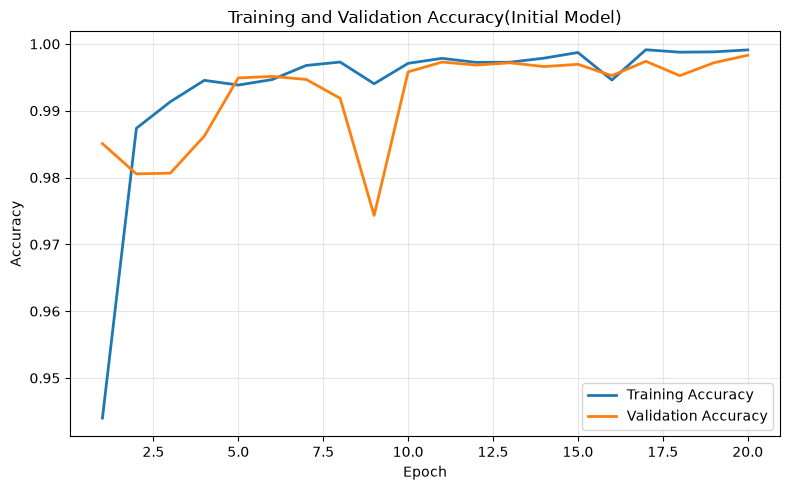

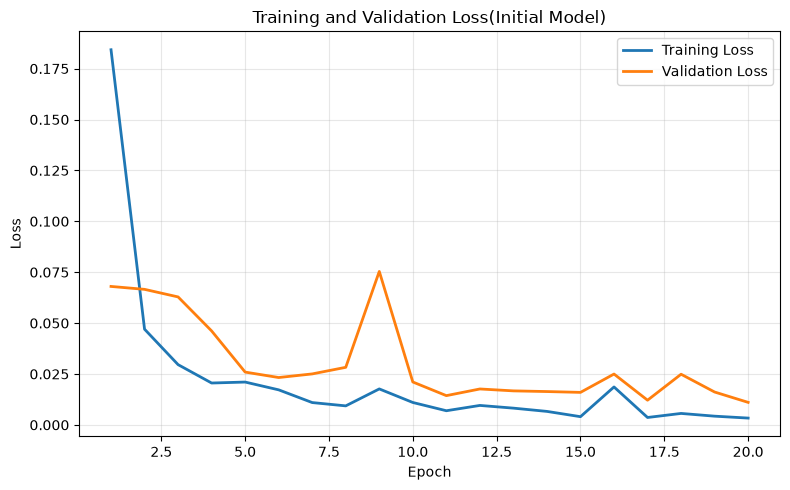

In [17]:
#---------------    Visualizing Training Progress -----------------------
import matplotlib.pyplot as plt
#A. Training and validation accuracy
history_dict = initial_history.history
epochs = range(1, len(history_dict['accuracy']) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history_dict["accuracy"], label="Training Accuracy", linewidth=2)
plt.plot(epochs, history_dict["val_accuracy"], label="Validation Accuracy", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy(Initial Model)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#B. Loss curves for training and validation
plt.figure(figsize=(8, 5))

plt.plot(epochs, history_dict["loss"], label="Training Loss", linewidth=2)
plt.plot(epochs, history_dict["val_loss"], label="Validation Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss(Initial Model)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)   
plt.tight_layout()
plt.show()



In [18]:
#------------- Mathematical Depiction of Best Validation Epoch ----------------
#Identify the epoch with the lowest validation loss, used as a
#reference point for assessing convergence and overfitting
best_epoch = np.argmin(history_dict["val_loss"]) + 1  
best_val_loss = np.min(history_dict["val_loss"])
best_val_accuracy = history_dict["val_accuracy"][best_epoch - 1]

print(f"Best Validation Epoch: {best_epoch}")
print(f"Best Validation Loss at Best Epoch: {best_val_loss:.4f}")
print(f"Best Validation Accuracy at Best Epoch: {best_val_accuracy:.4f}")


Best Validation Epoch: 20
Best Validation Loss at Best Epoch: 0.0111
Best Validation Accuracy at Best Epoch: 0.9983


##### 4.5.1 Interpretation of the Learning Curves 
The learning curves indicate that the initial network learns the classification task very rapidly. Training accuracy increased quickly during the early epochs and approached 100% by the end of training, while validation accuracy remained consistently high throughout, reaching values close to 99.7% in the later epochs.
The loss curves provide a complementary and more sensitive view of the model's generalisation behaviour. Training loss decreased steadily throughout training, and validation loss declined substantially during the earlier epochs, reaching its lowest observed value of 0.0136 at epoch 15, 3where validation accuracy stood at 0.9968(99.68%).
Beyond epoch 15, validation loss no longer showed a consistent downward trend, despite training performance remaining extremely high. This divergence is a hallmark of a model that has largely converged, where continued training yields diminishing or negligible benefit  to generalisation, even if training metrics continue ro improve marginally.
Notably, no large or sustained gap emerges between the training and validation accuracy curves, meaning severe overfitting is not evident from accuracy alone. This illustrates precisely why validation loss, rather than accuracy is the more informative signal for identifying an appropriate training duration. Once accuracy is already close to its ceiling, it has  little room left to reveal further degradation, whereas loss remains sensitive to subtler changes in prediction confidence even after accuracy has plateaued.
These observations show that the final epoch should not be automatically treated as the best model state, since the epoch of lowest validation loss(epoch 15) preceded the end of training. Subsequent experiments in this study will therefore compare model configurations using validation perfromance rather than final-epoch performance, while the test set remains held out entirely from the selection process. 

#### 4.6 Data Integrity Check
The initial neural network achieved near-perfect validation performance(section 4.4). While this may genuinely reflect strong visual separability between the six medical image categories, unusually high performance of this kind can also arise when identical or highly similar images appear across more than one data partition. This is usually referred to as data leakage.
To rule out this possibility, an additional integrity check is performed to identify exact duplicate images between the training and validation sets. Duplicates are identified by comparing the underlying pixel content of each image directly, rather than filenames, since identical images could plausibly be stored under different file names within the dataset.
If such duplicates exist, they would inflate validation performance artificially, that is, the model could effectively be evaluated on images it has already encountered leading to an overly optimistic estimate of its true ability to generalise to unseen data. Ruling this out is therefore an important precondition for interpreting the near perfect results reported in Section 4.4 with confidence.
Again, this check is performed using only the training and validation partitions consistent with the evaluation protocols established in section 1.4.


In [19]:
#--------------- Data Integrity Check ----------------
import hashlib

def image_hash(image_array):
    """Compute the SHA256 hash of an image's raw pixel data."""
    return hashlib.sha256(image_array.tobytes()).hexdigest()

#Build a set of hashes for every image in the training set
train_hashes = {image_hash(images[index]) for index in train_indices}

print(f"Number of unique hashes in training set: {len(train_hashes)}")

#Check for duplicates in the validation set by comparing hashes
duplicate_count = sum(
    image_hash(images[index]) in train_hashes for index in val_indices
)
print(f"Number of duplicate images in validation set: {duplicate_count}")

#Check for exact duplicate images across the entire dataset and not
#just between training and validation sets
all_hashes = [image_hash(image) for image in images]

total_images = len(all_hashes)
unique_hashes = len(set(all_hashes))

print(f"Total images: {total_images}, Unique images: {unique_hashes}, Duplicate images: {total_images - unique_hashes}")

#Inspecting the first few filenames in each class folder checking for
#naming patterns that show duplicated or related images 
for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)
    files = sorted(os.listdir(class_path))
    
    print(f"\n{class_name}:")
    print(files[:10])

Number of unique hashes in training set: 41046
Number of duplicate images in validation set: 85
Total images: 58954, Unique images: 58514, Duplicate images: 440

AbdomenCT:
['000000.jpeg', '000001.jpeg', '000002.jpeg', '000003.jpeg', '000004.jpeg', '000005.jpeg', '000006.jpeg', '000007.jpeg', '000008.jpeg', '000009.jpeg']

BreastMRI:
['000000.jpeg', '000001.jpeg', '000002.jpeg', '000003.jpeg', '000004.jpeg', '000005.jpeg', '000006.jpeg', '000007.jpeg', '000008.jpeg', '000009.jpeg']

CXR:
['000000.jpeg', '000001.jpeg', '000002.jpeg', '000003.jpeg', '000004.jpeg', '000005.jpeg', '000006.jpeg', '000007.jpeg', '000008.jpeg', '000009.jpeg']

ChestCT:
['000000.jpeg', '000001.jpeg', '000002.jpeg', '000003.jpeg', '000004.jpeg', '000005.jpeg', '000006.jpeg', '000007.jpeg', '000008.jpeg', '000009.jpeg']

Hand:
['000000.jpeg', '000001.jpeg', '000002.jpeg', '000003.jpeg', '000004.jpeg', '000005.jpeg', '000006.jpeg', '000007.jpeg', '000008.jpeg', '000009.jpeg']

HeadCT:
['000000.jpeg', '000001.jpeg

In [20]:
#-------------------- Further Integrity Checks ----------------
from collections import defaultdict

#Group image indices by pixel-content hash to identify potential duplicates or near-duplicates
hash_groups = defaultdict(list)

for index, image in enumerate(images):
    hash_groups[image_hash(image)].append(index)

duplicate_groups = {hash_value: indices for hash_value, indices in hash_groups.items() if len(indices) > 1}

#Flag duplicate groups whose images are labelled with more than one
#class, indicating potential mislabeling or data integrity issues
cross_class_duplicates = [
    (hash_value, indices, group_labels) for hash_value, indices in duplicate_groups.items()
    if len(group_labels := {labels[index] for index in indices}) > 1
]

print(f"Duplicate groups: {len(duplicate_groups)}, Cross-class duplicates: {len(cross_class_duplicates)}")

Duplicate groups: 348, Cross-class duplicates: 0


In [21]:
#------------------ Removing Duplicates ----------------
#Remove duplicate images by retaining only the first occurence of
#each unique pixel-content hash
seen_hashes = set()
keep_indices = []

for index, image in enumerate(images):
    current_hash = image_hash(image)
    
    if current_hash not in seen_hashes:
        seen_hashes.add(current_hash)
        keep_indices.append(index)
    
cleaned_images = images[keep_indices]
cleaned_labels = labels[keep_indices]

print(f"Original images: {len(images)}")
print(f"Unique images retained after duplicate removal: {len(cleaned_images)}")
print(f"Duplicate images removed: {len(images) - len(cleaned_images)}")

# Verify the class distribution after duplicate removal 
unique_labels, clean_class_counts = np.unique(cleaned_labels, return_counts=True)

print("Class distribution after deduplication:")
for label, count in zip(unique_labels, clean_class_counts):
    print(f"   {class_names[label]}: {count}") 


Original images: 58954
Unique images retained after duplicate removal: 58514
Duplicate images removed: 440
Class distribution after deduplication:
   AbdomenCT: 9654
   BreastMRI: 8954
   CXR: 9999
   ChestCT: 10000
   Hand: 10000
   HeadCT: 9907


In [22]:
#---------------------------- New Training / Test Split ------------------------
#Reconstruct the training, validation and test partitions from
#cleaned, duplicate-free dataset, using the same stratified
#splitting procedure and random seed as before 
all_indices = np.arange(len(cleaned_images))

train_val_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.15,
    random_state=SEED,
    stratify=cleaned_labels
)

validation_fraction = 15/85

train_indices, val_indices = train_test_split(
    train_val_indices,
    test_size=validation_fraction,
    random_state=SEED,
    stratify=cleaned_labels[train_val_indices]
)

x_train = cleaned_images[train_indices]
y_train = cleaned_labels[train_indices]

x_validation = cleaned_images[val_indices]
y_validation = cleaned_labels[val_indices]

x_test = cleaned_images[test_indices]
y_test = cleaned_labels[test_indices]

print(f"Training: {x_train.shape}")
print(f"Validation: {x_validation.shape}")
print(f"Test: {x_test.shape}")

Training: (40959, 64, 64)
Validation: (8777, 64, 64)
Test: (8778, 64, 64)


In [23]:
#---------------------------- Redoing Preprocessing -------------------------------
#Flatten each image as done in earlier split 
x_train = x_train.reshape(x_train.shape[0], 64 * 64).astype("float32") / 255.0
x_validation = x_validation.reshape(x_validation.shape[0], 64 * 64).astype("float32") / 255.0
x_test = x_test.reshape(x_test.shape[0], 64 * 64).astype("float32") / 255.0

print(f"Training shape: {x_train.shape}, dtype: {x_train.dtype}")
print(f"Validation shape: {x_validation.shape}, dtype: {x_validation.dtype}")
print(f"Test shape: {x_test.shape}, dtype: {x_test.dtype}")

Training shape: (40959, 4096), dtype: float32
Validation shape: (8777, 4096), dtype: float32
Test shape: (8778, 4096), dtype: float32


##### 4.6.1 Duplicate Image Analysis and Removal
The data integrity investigation identified exact duplicate images within the dataset. Of the 58,954 original image files, only 58,514 presented unique pixel content, indicating that 440 duplicate image instances were present, distributed across 348 duplicate groups. 
A further check examined whether any identical images had been assigned to different target classes. No cross-class duplicates were found, indicating that the duplication reflects redundant storage of images rather than any inconsistency or error in labelling.
However, the presence of exact duplicates remains significant because the original dataset was partitioned randomly at image level and did not account for duplicate content. This allowed identical images to be split across different partitions by chance. In the original split, 85 validation images were exact duplicates of training images, meaning the model had effectively seen them during training. The near perfect validation performance reported for the initial model is therefore likely to have been partially inflated by this leakage, rather than reflecting genuine generalisation.
To address this, a single copy of each unique image was retained, producing a cleaned dataset of 58,514 images. The training, validation and test partitions were reconstructed from this cleaned dataset using the same stratified splitting procedure as before(section 2.3).
In light of this finding, the initial model's results(Section 4.4) are best treated as preliminary, having motivated this integrity investigation rather than representing a reliable estimate of performance. All subsequent models are trained and evaluated exclusively on the cleaned duplicate-free dataset.

##### 4.6.2 Revised Dataset Partitioning 
Following the duplicate removal, the training, validation and test partitions were discarded and rebuilt from the cleaned dataset of 58,514 unique images, ensuring no identical image appear across multiple subsets.
The same stratified 70/15/15 split used earlier(Section 2.3) was applied, preserving the relative class distribution across all three partitions.

| Dataset Partition | Number of Images | Input Shape |
| :--- | :---: | ---: |
|Training | 40,959 | (40,959, 4096) |
|Validation| 8,777| (8,777, 4096) |
|Test | 8,778| (8,778, 4096) |
|Total | 58,514| |
As before, each image was reshaped into a 4096 value vector, converted to float32, and normalised to range [0, 1] by dividing by 255.
The new test set is reserved exclusively for the final evaluation of the selected model and will not inform any developmental decision including architecture, dropout rate, or training duration.
Rebuilding the partitions this way ensures that subsequent validation results give a more trustworthy indication of model generalisation than the preliminary results from the original duplicate-affected split.




#### 4.7 Re-evaluation Using the Cleaned Dataset
With the duplicate-free partitions now in place, the majority-class baseline and initial neural network are re-evaluated to establish a trustworthy reference point for subsequent comparisons. This step ensures that all later model comparisons rest on data free from the cross-partition duplication identified in Section 4.6.1, rather than on the potentially inflated results obtained from the original split.
Consistent with evaluation protocol described in Section 2.3, the revised test set remains untouched throughout this process and will be used only once, for the final evaluation of the selected model.



In [24]:
#----------------------------- Revised Majority Baseline -------------------------
#Identify the majority class in the cleaned training partition,
#used as the baseline classifier's constant prediction 
clean_class_counts = np.bincount(y_train)
clean_majority_label = np.argmax(clean_class_counts)

print(f"Majority class: {class_names[clean_majority_label]} and training observations in majority class: {clean_class_counts[clean_majority_label]}")

#Predict the majority class for every observation in revised set,
#forming the recalculated baseline

clean_baseline_predictions = np.full(y_validation.shape, clean_majority_label)

print(f"Baseline predictions shape: {clean_baseline_predictions.shape}")
print(f"Unique predicted values: {np.unique(clean_baseline_predictions)}")

#Compute baseline performance metrics on revised validation set,
#providing an updated reference point for comparison
clean_baseline_accuracy = accuracy_score(y_validation, clean_baseline_predictions)

clean_baseline_balanced_accuracy = balanced_accuracy_score(
    y_validation, clean_baseline_predictions
)

clean_baseline_f1 = f1_score(
    y_validation, clean_baseline_predictions, average="macro", zero_division=0
)

print("Revised baseline performance metrics:")
print(f"Accuracy: {clean_baseline_accuracy:.4f}")
print(f"Balanced accuracy: {clean_baseline_balanced_accuracy:.4f}")
print(f"Macro F1-score: {clean_baseline_f1:.4f}")


Majority class: ChestCT and training observations in majority class: 7000
Baseline predictions shape: (8777,)
Unique predicted values: [3]
Revised baseline performance metrics:
Accuracy: 0.1709
Balanced accuracy: 0.1667
Macro F1-score: 0.0487


##### 4.7.1 Revised Majority-Class Baseline
The majority-class baseline is recalculated using the cleaned training partition, following the same procedure established in Section 3. The revised baseline is evaluated using the same metrics as before allowing it to serve as a like-for-like reference point against which subsequent neural network models, trained and evaluated on the cleaned dataset, can be meaningfully compared.
Using the cleaned dataset, the majority-class classifier identified Chest CT as the most frequent class in the training partition(7,000 observations) and assigned it to every validation image.
The revised baseline achieved an accuracy of 0.1709(17.09%), a balanced accuracy of 0.1667(16.67%), and a macro F1-score of 0.0487. This is very similar to the original results, confirming that duplicate removal did not meaningfully alter the class distribution. As before, balanced accuracy sits at approximately one-sixth, and the low macro F1-score reflects the fact that five of the six classes are never predicted.
This confirms the revised baseline as a valid reference point for evaluating the neural network models developed on the cleaned dataset. All subsequent comparisons will use this cleaned validation partition, with the revised test set held out until final evaluation.

##### 4.7.2 Revised Initial Neural Network Model
The initial neural network is retrained using the cleaned training and validation partitions while maintaining the same architecture and training configuration as before. This ensures that any changes in performance can be attributed to duplicate removal rather than changes to the modelling approach.
The network retains two hidden Dense layers with 64 and 32 neurons, respectively, using ReLU activation, followed by a six-unit softmax output layer. The model is trained for 20 epochs with a batch size of 128. Training and validation performance are monitored throughout, while the revised test set remains unused.
The resulting validation performance is compared with both the revised baseline and the preliminary pre-cleaning results. However, only results obtained from the cleaned dataset will be used for subsequent model selection and the final conclusions.


In [25]:
#-------------------------------- Building a New Model -------------------------------
#Rebuild the initial architecture (Section 4.1) on cleaned dataset 
tf.random.set_seed(SEED)

clean_initial_model = keras.Sequential(
    [
        layers.Input(shape=(4096,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(6, activation="softmax")
    ]
)

clean_initial_model.summary()

#Compile using the same optimiser, loss, and, metric as the original model
clean_initial_model.compile(
    optimizer = "adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

#Retrain the initial architecture on cleaned dataset, using the epoch count count 
clean_initial_history = clean_initial_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_validation, y_validation),
    verbose=1
    
)

#Evaluate the retrained model on the cleaned validation set 
clean_validation_loss, clean_validation_accuracy = clean_initial_model.evaluate(
    x_validation, y_validation, verbose=0
)

print(f"Validation loss: {clean_validation_loss:.4f}")
print(f"Validation accuracy: {clean_validation_accuracy:.4f}")

#Generate class predictions on the cleaned validation set by taking
#the argmax of the model's prediction probability distribution 
clean_validation_probabilities = clean_initial_model.predict(x_validation, verbose=0)

clean_validation_predictions = np.argmax(clean_validation_probabilities, axis=1)

print(f"Unique predicted classes: {np.unique(clean_validation_predictions)}")

#Compute performance metrics for the retained model on the cleaned 
#validation set, for comparison against the revised baseline and the preliminary model results
clean_initial_accuracy = accuracy_score(y_validation, clean_validation_predictions)

clean_initial_balanced_accuracy = balanced_accuracy_score(
    y_validation, clean_validation_predictions
)

clean_initial_f1 = f1_score(
    y_validation, clean_validation_predictions, average="macro", zero_division=0
)

print("Revised initial model performance metrics:")
print(f"Accuracy: {clean_initial_accuracy:.4f}")
print(f"Balanced accuracy: {clean_initial_balanced_accuracy:.4f}")
print(f"Macro F1-score: {clean_initial_f1}")

# Final Comparison
print("Revised Baseline vs Initial Model")
print("---------------------------------")

print(
    f"Accuracy: "
    f"{clean_baseline_accuracy:.4f} -> "
    f"{clean_initial_accuracy:.4f}"
)

print(
    f"Balanced Accuracy: "
    f"{clean_baseline_balanced_accuracy:.4f} -> "
    f"{clean_initial_balanced_accuracy:.4f}"
)

print(
    f"Macro F1: "
    f"{clean_baseline_f1:.4f} -> "
    f"{clean_initial_f1:.4f}"
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264,486 (1.01 MB)

 Trainable params: 264,486 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9565 - loss: 0.1481 - val_accuracy: 0.9699 - val_loss: 0.0884
Epoch 2/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9888 - loss: 0.0439 - val_accuracy: 0.9876 - val_loss: 0.0420
Epoch 3/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9894 - loss: 0.0357 - val_accuracy: 0.9894 - val_loss: 0.0331
Epoch 4/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9948 - loss: 0.0190 - val_accuracy: 0.9951 - val_loss: 0.0211
Epoch 5/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9961 - loss: 0.0139 - val_accuracy: 0.9957 - val_loss: 0.0174
Epoch 6/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9943 - loss: 0.0163 - val_accuracy: 0.9964 - val_loss: 0.0141
Epoch 7/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9967 - loss: 0.0107 - val_accuracy: 0.9979 - val_loss: 0.0113
Epoch 8/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9975 - loss: 0.0082 - val_accuracy: 0.

##### 4.7.2 Revised Initial Neural Network Model
The initial architecture was retrained on the cleaned partitions using the same configuration as the preliminary model in Section 4.3. This was done to isolate the effect of duplicate removal.
The revised model achieved a validation accuracy of 0.9977 (99.77%), a balanced accuracy of 0.9978, and a macro F1-score of 0.9977. This represents a substantial improvement over the revised baseline, which achieved 17.09% accuracy, 16.67% balanced accuracy, and a macro F1-score of 0.0487. The consistency across all three metrics indicates balanced performance across all six classes rather than reliance on the most frequent categories.
Near-perfect performance persisted even after exact duplicate images were removed, suggesting that the original result was not driven solely by duplicate-image leakage. This may indicate that the six categories contain highly distinctive visual characteristics that can be learned even from flattened pixel representations.
Some caution is still necessary. The dataset does not provide patient or scan identifiers, meaning that related images from the same patient or imaging study could potentially appear across different data partitions. The results therefore demonstrate strong performance on this dataset but should not be interpreted as evidence of clinical generalisation.
Only results obtained from the cleaned dataset are used in subsequent model comparison, model selection, and final conclusions.

##### 4.7.3 Revised Training and Validation Learning Curves 
The training history of the revised initial model is examined to assess how performance develops across the 20 training epochs, following the same approach used for the preliminary model in Section 4.5.
Training and validation accuracy are compared to evaluate classification performance, while training and validation loss are examined to assess convergence and identify any signs of overfitting. Particular attention is given to the epoch with the lowest validation loss, as this represents the point at which generalisation performance was strongest, consistent with the reasoning applied in Section 4.5.
These learning curves are used only to examine the training behaviour of the revised initial model. The test set remains unused throughout this stage.




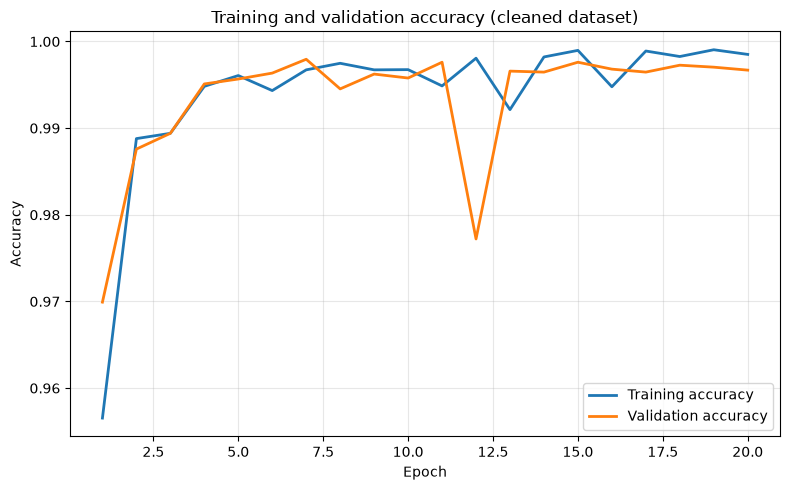

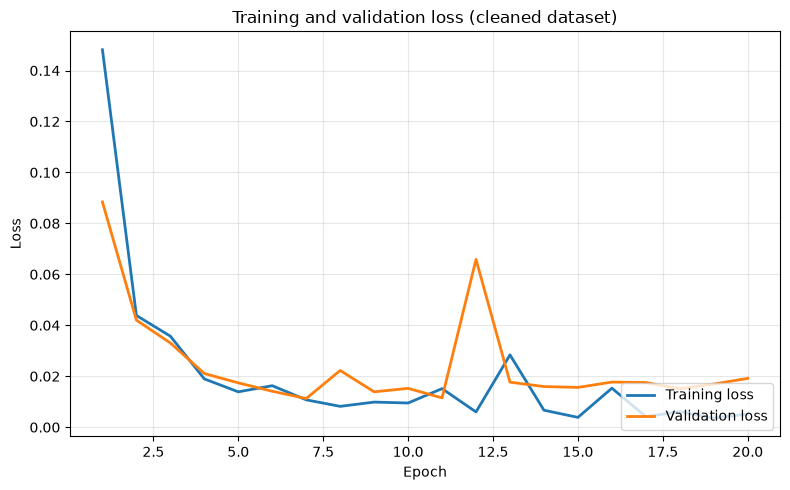

Best validation epoch: 7
Best validation loss: 0.0113
Validation accuracy at best epoch: 0.9979


In [26]:
#--------------------------- Visualisation of New Code -------------------------------
#A. Accuracy 
clean_history = clean_initial_history.history
epochs = range(1, len(clean_history["accuracy"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, clean_history["accuracy"], label="Training accuracy", linewidth=2)
plt.plot(epochs, clean_history["val_accuracy"], label="Validation accuracy", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy (cleaned dataset)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#B. Loss 
plt.figure(figsize=(8,5))

plt.plot(epochs, clean_history["loss"], label="Training loss", linewidth=2)
plt.plot(epochs, clean_history["val_loss"], label="Validation loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss (cleaned dataset)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Identify the epoch with the lowest validation loss for new model
best_clean_epoch = np.argmin(clean_history["val_loss"]) + 1
best_clean_val_loss = np.min(clean_history["val_loss"])
best_clean_val_accuracy = clean_history["val_accuracy"][best_clean_epoch - 1]

print(f"Best validation epoch: {best_clean_epoch}")
print(f"Best validation loss: {best_clean_val_loss:.4f}")
print(f"Validation accuracy at best epoch: {best_clean_val_accuracy:.4f}")




##### 4.7.3 Revised Training and Validation Learning Curves
The revised learning curves show that the network continued to learn very effectively after duplicate removal, with both training and validation accuracy increasing rapidly and remaining close to 100% throughout most of the training process.
The lowest validation loss, 0.0093, occurred at epoch 15 and corresponded to a validation accuracy of 99.79%. This indicates that the model achieved its strongest generalisation performance before the final epoch. After epoch 15, further improvement was minimal, suggesting that the network had largely converged and reinforcing the importance of considering validation loss rather than relying solely on final-epoch performance when assessing model behaviour.
No substantial overfitting is evident, as training and validation performance remain closely aligned throughout. The consistently near-perfect results may reflect highly distinguishable visual characteristics across the six image categories, making the classification task relatively easy for the network.
The best-epoch finding applies specifically to the current architecture. Since models with different capacities or dropout configurations may converge differently, training duration will continue to be assessed separately for each subsequent experiment rather than being fixed at 15 epochs.

### 5. Systematic Model Experiments
With a validated initial model now established, a series of controlled experiments is conducted to investigate how different modelling choices affect performance and generalisation.
These experiments focus on factors permitted within the scope of the assignment: network capacity, network depth, dropout regularisation, and training duration. To ensure that comparisons remain interpretable, one principal factor is varied at a time while all other training conditions are kept as constant as possible.
Models are compared using validation loss, accuracy, balanced accuracy, and macro F1-score, with particular emphasis placed on validation performance. Training performance alone cannot determine how well a model generalises to unseen data.
The cleaned test partition remains completely excluded from all experiments and model-selection decisions. It will be used only after the final model configuration has been selected.

#### 5.1 Model Capacity Experiment
The first experiment investigates the effect of network capacity, referring to the number of trainable units available to the model.
The revised initial network contains hidden layers of 64 and 32 neurons. To determine whether this level of capacity is necessary for the classification task, smaller and larger networks are compared while retaining two hidden layers and the same activation functions, optimiser, batch size and training duration.
Five configurations are evaluated:

| Model| First Hidden Layer |Second Hidden Layer |
| :--- | :--- | :--- |
| Very Small |8| 4 |
| Small| 16| 8|
| Medium | 32 | 16 |
| Initial | 64 | 32 |
| Large | 128 | 64 |

This range allows both under-capacity and higher-capacity networks to be examined. Each model is trained using the same cleaned training partition and evaluated using the same validation partition. The test set is not used during this experiment.



In [27]:
#------------------------- Model Experiments -------------------------------
def build_capacity_model(first_units, second_units):
    """ 
    Build and compile two hidden layer Dense network for 
    the capacity experiments, with configurable layer widths
    
    Parameters
    -----------
    first_units : int 
         Number of neurons in the first hidden layer
    second_units : int 
         Numb4er of neurons in the second hidden layer
    
    Returns
    -------
    keras.Sequential
         A compiled model ready for training    
    """
    model = keras.Sequential(
        [
            layers.Input(shape=(4096,)),
            layers.Dense(first_units, activation="relu"),
            layers.Dense(second_units, activation="relu"),
            layers.Dense(6, activation="softmax")
        ]
       
    )
    
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

#Layer-width configurations to be compared in the capacity
#experiment, ranging from small to large, and initial 
#matching section 4
capacity_configs = {
    "Very Small": (8, 4),
    "Small": (16, 8),
    "Medium": (32, 16),
    "Initial": (64, 32),
    "Large": (128, 64)
}

#Store history and summary metrics for each capacity
capacity_histories = {}
capacity_results = []

# Train and evaluate each model for each capacity configuration
for model_name, units in capacity_configs.items():

    print(f"\nTraining {model_name} model...")

    keras.backend.clear_session()
    keras.utils.set_random_seed(SEED)

    model = build_capacity_model(
        units[0],
        units[1]
    )

    restore_best = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )

    history = model.fit(
        x_train,
        y_train,
        epochs=20,
        batch_size=128,
        validation_data=(
            x_validation,
            y_validation
        ),
        callbacks=[restore_best],
        verbose=0
    )

    capacity_histories[model_name] = history.history

    best_index = np.argmin(
        history.history["val_loss"]
    )

    best_epoch = best_index + 1

    best_val_loss = history.history[
        "val_loss"
    ][best_index]

    best_val_accuracy = history.history[
        "val_accuracy"
    ][best_index]

    validation_probabilities = model.predict(
        x_validation,
        verbose=0
    )

    validation_predictions = np.argmax(
        validation_probabilities,
        axis=1
    )

    balanced_accuracy = balanced_accuracy_score(
        y_validation,
        validation_predictions
    )

    macro_f1 = f1_score(
        y_validation,
        validation_predictions,
        average="macro",
        zero_division=0
    )

    capacity_results.append({
        "Model": model_name,
        "Layer 1": units[0],
        "Layer 2": units[1],
        "Best Epoch": best_epoch,
        "Best Val Loss": best_val_loss,
        "Best Val Accuracy": best_val_accuracy,
        "Balanced Accuracy": balanced_accuracy,
        "Macro F1": macro_f1
    })


capacity_results_df = pd.DataFrame(capacity_results)




capacity_results_df
    
    
    

    



Training Very Small model...


Training Small model...

Training Medium model...

Training Initial model...

Training Large model...


,Model,Layer 1,Layer 2,Best Epoch,Best Val Loss,Best Val Accuracy,Balanced Accuracy,Macro F1
0,Very Small,8,4,20,0.111654,0.980403,0.980672,0.980451
1,Small,16,8,16,0.020119,0.995101,0.995214,0.995176
2,Medium,32,16,14,0.014306,0.997152,0.997212,0.997194
3,Initial,64,32,15,0.012319,0.997607,0.997657,0.997632
4,Large,128,64,19,0.011486,0.997721,0.997764,0.997756


##### 5.1.1 Interpretation of the Model Capacity
The model-capacity experiment demonstrates that increasing the number of hidden units generally improves classification performance on the cleaned validation set, although the gains become progressively smaller as network capacity increases.
The Very Small network, with 8 and 4 hidden neurons, produced the weakest results, achieving a best validation accuracy of 0.9804, balanced accuracy of 0.9807, and macro F1-score of 0.9805. Although this performance remains substantially above the majority-class baseline, it suggests that this architecture has insufficient capacity to model the task as effectively as the larger networks.
Performance improved progressively as the hidden-layer sizes increased. The Small model achieved a validation accuracy of 0.9951, while the Medium model improved further to 0.9972. Beyond this point, however, the gains became marginal. The Initial model achieved 0.9976 validation accuracy, while the Large model produced the strongest overall results, with 0.9977 accuracy, 0.9978 balanced accuracy, 0.9978 macro F1-score, and the lowest validation loss of 0.0115.
The difference between the Initial and Large models was minimal, representing an improvement of approximately 0.01 percentage points in accuracy, despite the Large model containing twice as many hidden units as the Initial configuration. This pattern is consistent with diminishing returns to network capacity. Once a network is sufficiently large to represent the underlying structure of the data, adding further parameters provides little additional benefit and may increase computational cost without meaningfully improving generalisation.
Overall, these results suggest that very small networks under-represent the task, while medium-sized and larger networks are capable of modelling it extremely effectively. Although the Large model achieved the strongest numerical performance, its negligible improvement over the considerably smaller Initial model indicates that increasing capacity beyond a certain point does not produce meaningful gains in predictive performance for this task.



#### 5.2 Network Depth Experiment 
The second systematic experiment investigates the effect of network depth, defined here as the number of hidden Dense layers.
To isolate this factor, the first hidden layer is fixed at 64 neurons across all configurations. Additional hidden layers are then progressively added, with each new layer containing fewer neurons than the preceding layer. All other conditions, including the optimiser, activation functions, batch size, maximum training duration, and cleaned training and validation partitions, are held constant across configurations. This is consistent with the one-factor-at-a-time approach established in Section 5.
Four network depths are compared:


| Model               | Hidden Layer Architecture |
| ------------------- | ------------------------- |
| One Hidden Layer    | 64                        |
| Two Hidden Layers   | 64 -> 32                |
| Three Hidden Layers | 664 -> 32 -> 16           |
| Four Hidden Layers  | 64 -> 32 -> 16 -> 8       |

All hidden layers use ReLU activation, while the six-neuron output layer uses softmax activation. Each model is trained for a maximum of 20 epochs. The weights corresponding to the lowest validation loss are then restored before the validation metrics are calculated. This ensures that each configuration is evaluated at its own point of strongest generalisation rather than at an arbitrary final epoch.
This experimental design isolates the effect of network depth from other architectural and training factors. Consequently, observed differences in performance can be attributed primarily to the number of hidden layers rather than to changes in layer width or training conditions. As with all preceding experiments, the test set remains fully excluded from model development and comparison.



In [28]:
#---------------------- Testing Network Depth ----------------------------
def build_depth_model(hidden_units):
    """ 
    Build and compile a Dense network with configurable number of 
    hidden layers, for the network-depth experiment
    
    Parameters
    ----------
    hidden_units : list of int
      Number of neurons in each hidden layer, in order. The number 
      of hidden layers is inferred from the length of this list
    
    Returns
    --------
    keras.Sequential
      A compiled model ready for training 
    """
    model = keras.Sequential()
    model.add(layers.Input(shape=(4096,)))
    
    for units in hidden_units:
        model.add(layers.Dense(units, activation="relu"))
    
    model.add(layers.Dense(6, activation="softmax"))
    
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

#Hidden layer configurations for the network-depth experiment
depth_configs = {
    "One Hidden Layer": [64],
    "Two Hidden Layers": [64, 32],
    "Three Hidden Layers": [64, 32, 16],
    "Four Hidden Layers": [64, 32, 16, 8]
}

depth_histories = {}
depth_results = []

#Train and evaluate a model for each network-depth configuration
for model_name, hidden_units in depth_configs.items():

    print(f"\nTraining {model_name}...")

    keras.backend.clear_session()
    keras.utils.set_random_seed(SEED)

    model = build_depth_model(
        hidden_units
    )

    restore_best = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )

    history = model.fit(
        x_train,
        y_train,
        epochs=20,
        batch_size=128,
        validation_data=(
            x_validation,
            y_validation
        ),
        callbacks=[restore_best],
        verbose=0
    )

    depth_histories[model_name] = history.history

    best_index = np.argmin(
        history.history["val_loss"]
    )

    best_epoch = best_index + 1

    best_val_loss = history.history[
        "val_loss"
    ][best_index]

    best_val_accuracy = history.history[
        "val_accuracy"
    ][best_index]

    validation_probabilities = model.predict(
        x_validation,
        verbose=0
    )

    validation_predictions = np.argmax(
        validation_probabilities,
        axis=1
    )

    balanced_accuracy = balanced_accuracy_score(
        y_validation,
        validation_predictions
    )

    macro_f1 = f1_score(
        y_validation,
        validation_predictions,
        average="macro",
        zero_division=0
    )

    depth_results.append({
        "Model": model_name,
        "Architecture": " -> ".join(
            str(units)
            for units in hidden_units
        ),
        "Best Epoch": best_epoch,
        "Best Val Loss": best_val_loss,
        "Best Val Accuracy": best_val_accuracy,
        "Balanced Accuracy": balanced_accuracy,
        "Macro F1": macro_f1
    })
    

#Converting the depth-experiment results into a DataFrame
depth_results_df = pd.DataFrame(
    depth_results
)

depth_results_df



Training One Hidden Layer...

Training Two Hidden Layers...

Training Three Hidden Layers...

Training Four Hidden Layers...


,Model,Architecture,Best Epoch,Best Val Loss,Best Val Accuracy,Balanced Accuracy,Macro F1
0,One Hidden Layer,64,19,0.014796,0.997607,0.997662,0.997635
1,Two Hidden Layers,64 -> 32,15,0.012319,0.997607,0.997657,0.997632
2,Three Hidden Layers,64 -> 32 -> 16,16,0.014476,0.997038,0.997102,0.997085
3,Four Hidden Layers,64 -> 32 -> 16 -> 8,12,0.015956,0.995784,0.995865,0.995849


##### 5.2.1 Interpretation of the Network Depth Experiment
The network-depth experiment shows that increasing depth beyond a certain point does not necessarily improve validation performance.
The One hidden layer model achieved a validation accuracy of 0.9976, balanced accuracy of 0.9977, and macro F1-score of 0.9976. Adding a second hidden layer improved performance, with the Two hidden layers configuration producing the strongest overall results. It achieved the lowest validation loss of 0.0115 and the highest accuracy, balanced accuracy, and macro F1-score, all at 0.9982. Beyond this point, performance declined. The Three hidden layers model achieved a slightly lower validation accuracy of 0.9976, while the Four hidden layers model performed worst among the deeper configurations, with an accuracy of 0.9960 and a validation loss of 0.0174.
These results suggest that two hidden layers provide sufficient representational capacity for this task, while additional depth increases model complexity without improving generalisation.
One limitation should be considered. The One hidden layer model reached its lowest validation loss at epoch 20, which was the maximum training duration used in the experiment. This means that its true optimum may not have been fully captured within the available training window. Nevertheless, under the same conditions applied to all four models, the Two hidden layers configuration produced the strongest overall validation performance. The experiment therefore provides no evidence that increasing network depth beyond two hidden layers improves performance on the cleaned dataset.


#### 5.3 Dropout Regularisation Experiment
The third systematic experiment investigates whether dropout regularisation improves the generalisation of the two-hidden-layer network identified in Section 5.2.
Dropout works by randomly setting a proportion of hidden-layer activations to zero during training. This prevents the network from relying too heavily on individual neurons and encourages it to learn more distributed and robust representations, which can help reduce overfitting.
The 64 -> 32 architecture is retained because it produced the strongest performance in the network-depth experiment. To isolate the effect of regularisation, the architecture, optimiser, activation functions, batch size, and maximum training duration are held constant. Only the dropout rate is varied across configurations, consistent with the one-factor-at-a-time approach used throughout this study.
Four dropout configurations are compared:

| Model| Dropout Rate |
| :--- | :--- |
| No dropout | 0 |
| Low dropout | 0.2|
| Moderate Dropout | 0.3|
| High Dropout | 0.5|

The same dropout rate is applied after each hidden Dense layer. As in the depth experiment, each model is trained for a maximum of 20 epochs, with the weights corresponding to the lowest validation loss restored before the validation metrics are calculated.
Performance is compared using validation loss, validation accuracy, balanced accuracy, and macro F1-score. The test set remains excluded from all model-development and model-selection decisions, consistent with the overall evaluation protocol established in Section 5.



In [30]:
#------------------------ Dropout Regularisation Experiment --------------------------------
def build_drop_out_model(dropout_rate):
    """
    Build and compile the 64->32 architecture from section 5.2,
    with a Dropout Layer of the given rate applied after each hidden Dense layer
    
    Parameters
    ----------
    dropout_rate : float
       Proportion of activations to randomly set to zero
       
    Returns
    ---------
    keras.Sequential
      A compiled model ready for training
      
    """
    model = keras.Sequential([
        layers.Input(shape=(4096,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(32, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(6, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

#Define the dropout configurations 
dropout_configs = {
    "No Dropout": 0.0,
    "Low Dropout": 0.2,
    "Moderate Dropout": 0.3,
    "High Dropout": 0.5
}

#Containers for result 
dropout_histories = {}
dropout_results = []

#Train models 
for model_name, dropout_rate in dropout_configs.items():

    print(f"\nTraining {model_name} model...")

    keras.backend.clear_session()
    keras.utils.set_random_seed(SEED)

    model = build_drop_out_model(
        dropout_rate
    )

    restore_best = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )

    history = model.fit(
        x_train,
        y_train,
        epochs=20,
        batch_size=128,
        validation_data=(
            x_validation,
            y_validation
        ),
        callbacks=[restore_best],
        verbose=0
    )

    dropout_histories[model_name] = history.history

    best_index = np.argmin(
        history.history["val_loss"]
    )

    best_epoch = best_index + 1

    best_val_loss = history.history[
        "val_loss"
    ][best_index]

    best_val_accuracy = history.history[
        "val_accuracy"
    ][best_index]

    validation_probabilities = model.predict(
        x_validation,
        verbose=0
    )

    validation_predictions = np.argmax(
        validation_probabilities,
        axis=1
    )

    balanced_accuracy = balanced_accuracy_score(
        y_validation,
        validation_predictions
    )

    macro_f1 = f1_score(
        y_validation,
        validation_predictions,
        average="macro",
        zero_division=0
    )

    dropout_results.append({
        "Model": model_name,
        "Dropout Rate": dropout_rate,
        "Best Epoch": best_epoch,
        "Best Val Loss": best_val_loss,
        "Best Val Accuracy": best_val_accuracy,
        "Balanced Accuracy": balanced_accuracy,
        "Macro F1": macro_f1
    })

#Results in DataFrame 
dropout_results_df = pd.DataFrame(
    dropout_results
)

dropout_results_df





Training No Dropout model...

Training Low Dropout model...

Training Moderate Dropout model...

Training High Dropout model...


,Model,Dropout Rate,Best Epoch,Best Val Loss,Best Val Accuracy,Balanced Accuracy,Macro F1
0,No Dropout,0.0,15,0.012319,0.997607,0.997657,0.997632
1,Low Dropout,0.2,15,0.019522,0.996240,0.996321,0.996278
2,Moderate Dropout,0.3,7,0.024773,0.994873,0.994966,0.994937
3,High Dropout,0.5,12,0.085647,0.987353,0.987652,0.987530


##### 5.3.1 Interpretation of the Dropout Experiment
The dropout experiment shows that regularisation did not improve validation performance for the two-hidden-layer network. Instead, performance declined progressively as the dropout rate increased.
The model with no dropout produced the strongest results, achieving a validation loss of 0.0123, accuracy of 0.9976, balanced accuracy of 0.9977, and macro F1-score of 0.9976. A dropout rate of 0.2 produced only a small reduction in accuracy, to 0.9962. Further increases in dropout resulted in larger declines. A dropout rate of 0.3 reduced accuracy to 0.9949, while the 0.5 configuration performed worst overall, with an accuracy of 0.9874, balanced accuracy of 0.9877, macro F1-score of 0.9875, and a substantially higher validation loss of 0.0856.
This consistent downward trend indicates that dropout is not beneficial for this architecture on the current dataset. This finding is consistent with the learning curves examined earlier in Section 4.7.3, which showed little evidence of meaningful overfitting in the unregularised network. Since dropout is primarily intended to reduce overfitting, its lack of benefit is unsurprising when there is little overfitting to correct. Instead, randomly deactivating hidden-layer activations during training appears to have reduced the effective capacity of the network without producing a corresponding improvement in generalisation.
On this basis, the unregularised 64 -> 32 architecture is preferred over the dropout configurations evaluated in this experiment.


#### 5.4 Experimental Summary and Model Selection
The systematic experiments examined three aspects of network design: capacity, depth, and dropout regularisation. Model selection is based exclusively on the cleaned training and validation partitions, while the test set has remained unused throughout.
The capacity experiment showed substantial improvements when moving from very small to medium-sized networks, but diminishing returns beyond the 64 -> 32 configuration. The larger 128 -> 64 network achieved only marginally higher performance, despite its greater complexity.
The depth experiment identified two hidden layers as the strongest configuration. Adding a third or fourth hidden layer did not improve performance and instead produced slightly weaker generalisation, suggesting that additional depth is unnecessary for this task.
The dropout experiment found no evidence that regularisation improved performance. The unregularised model achieved the strongest results across all metrics, while performance declined progressively as the dropout rate increased. This finding is consistent with the earlier learning curves, which showed little evidence of overfitting for dropout to correct.
Considering both predictive performance and model complexity, the 64 -> 32 two-hidden-layer architecture without dropout is selected for final evaluation. Although the 128 -> 64 model achieved marginally higher performance in the capacity experiment, the difference of approximately 0.01 percentage points in validation accuracy does not justify doubling the hidden-layer widths.
The table below summarises the final selected model configuration, including the input size, hidden-layer structure and activation functions, dropout setting, output layer, optimiser, loss function, and batch size used for final evaluation.


| Component| Selected Configuration |
| :--- | :--- |
| Input Features | 4,096|
| First hidden layer | 64 neurons, ReLU |
| Second hidden layer| 32 neurons, ReLU |
| Dropout| None |
| Output layer| 6 neurons, softmax|
| Optimiser | Adam |
| Loss function 1 | Sparse categorical cross-entropy |
| Batch size | 128 |

Training duration will be determined from the validation behaviour observed during model development. No further architectural or hyperparameter changes will be made once the test set is evaluated.


### 6. Final Model
hidden Dense layers containing 64 and 32 neurons, respectively, with ReLU activation and no dropout regularisation. The output layer contains six neurons with softmax activation for multiclass classification.
This architecture was selected using only the cleaned training and validation partitions. Although the larger 128 -> 64 configuration achieved marginally higher validation performance in the capacity experiment described in Section 5.1, the improvement was negligible relative to the additional model complexity. Increasing network depth beyond two hidden layers in Section 5.2 and introducing dropout regularisation in Section 5.3 also failed to improve generalisation.
The architecture and all training settings are now fixed. No further changes will be made in response to test-set performance.
Since the optimal validation epoch varied slightly across the experiments, the final model is trained within the same maximum 20-epoch window used throughout model development. The weights corresponding to the lowest validation loss are restored after training. This allows the training duration to be determined entirely from validation performance while preserving the test partition for a single, final, independent evaluation.

#### 6.1 Final Model Architecture
The selected network receives 4,096 normalised pixel values as input. These values are passed through two hidden Dense layers containing 64 and 32 neurons, respectively, before classification by a six-unit softmax output layer.
The model is compiled using the Adam optimiser and sparse categorical cross-entropy loss, consistent with the models evaluated in Section 5. Accuracy is monitored directly during training, while balanced accuracy and macro F1-score are calculated separately during the final evaluation, in line with the evaluation metrics used throughout this study.



In [31]:
#----------------------------- Final Model ------------------------------------
#Build the final selected architecture 
keras.backend.clear_session()
keras.utils.set_random_seed(SEED)

final_model = keras.Sequential([
    layers.Input(shape=(4096,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(6, activation="softmax")
])

final_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

final_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264,486 (1.01 MB)

 Trainable params: 264,486 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

#### 6.2 Final Model Training 
The final model is trained on the cleaned training partition using a batch size of 128 for a maximum of 20 epochs, consistent with the training configuration used throughout Section 5. Validation loss is monitored throughout training, and the weights corresponding to the lowest validation loss are restored once training is complete.
The validation partition continues to serve solely as a model-development resource, informing this final training run just as it did throughout the earlier experiments. The test partition remains completely unused at this stage and is reserved exclusively for the final independent evaluation.


In [34]:
#------------------- Training Final Model -------------------------
#Train the final model, restoring the weights from epoch
#with lowest validation loss
restore_best = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

final_history = final_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_validation, y_validation),
    callbacks=[restore_best],
    verbose=1
)

#Final Selected Epoch 
final_history_data = final_history.history

final_best_index = np.argmin(
    final_history_data["val_loss"]
)

final_best_epoch = final_best_index + 1

final_best_val_loss = final_history_data[
    "val_loss"
][final_best_index]

final_best_val_accuracy = final_history_data[
    "val_accuracy"
][final_best_index]

print(
    f"Selected epoch: {final_best_epoch}"
)

print(
    f"Best validation loss: "
    f"{final_best_val_loss:.4f}"
)

print(
    f"Validation accuracy at selected epoch: "
    f"{final_best_val_accuracy:.4f}"
)


Epoch 1/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9990 - loss: 0.0037 - val_accuracy: 0.9958 - val_loss: 0.0271
Epoch 2/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9994 - loss: 0.0029 - val_accuracy: 0.9978 - val_loss: 0.0169
Epoch 3/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9964 - loss: 0.0121 - val_accuracy: 0.9958 - val_loss: 0.0248
Epoch 4/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9994 - loss: 0.0030 - val_accuracy: 0.9986 - val_loss: 0.0145
Epoch 5/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9997 - loss: 0.0018 - val_accuracy: 0.9979 - val_loss: 0.0163
Epoch 6/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9994 - loss: 0.0025 - val_accuracy: 0.9983 - val_loss: 0.0152
Epoch 7/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9998 - loss: 0.0011 - val_accuracy: 0.9974 - val_loss: 0.0161
Epoch 8/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9999 - loss: 9.2199e-04 - val_accuracy

### 7. Final Test Evaluation 
Following the completion of model development and selection in Sections 5 and 6, the final model is evaluated on the reserved test partition. This represents the first use of the test data anywhere in the study.
The test set contains 8,778 images that were excluded from architecture selection, network-depth and dropout experiments, training-duration decisions, and all other model-development choices. It therefore provides an independent estimate of the selected model's performance on unseen observations from the available dataset, consistent with the evaluation protocol established earlier in the study.
Evaluation is conducted using accuracy, balanced accuracy, and macro F1-score, consistent with the metrics used throughout model development. In addition, class-level precision, recall, and F1-scores are examined to determine whether strong overall performance is accompanied by consistent performance across all categories. A confusion matrix is also used to identify the specific types of classification errors made by the final model.
Consistent with the evaluation protocol, the test results are used solely to report the final performance of the selected model. No further model tuning or architectural changes will be made in response to these results.



In [35]:
#------------------------------ Overall Performance -------------------------------
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# Evaluate the final model on the reserved test set
test_loss, test_accuracy = final_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

test_probabilities = final_model.predict(
    x_test,
    verbose=0
)

test_predictions = np.argmax(
    test_probabilities,
    axis=1
)


test_balanced_accuracy = balanced_accuracy_score(
    y_test,
    test_predictions
)

test_macro_f1 = f1_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

print("Final Test Performance")
print("----------------------")
print(f"Test Loss: {test_loss:.4f}")
print(f"Accuracy: {test_accuracy:.4f}")
print(
    f"Balanced Accuracy: "
    f"{test_balanced_accuracy:.4f}"
)
print(
    f"Macro F1-Score: "
    f"{test_macro_f1:.4f}"
)


Final Test Performance
----------------------
Test Loss: 0.0115
Accuracy: 0.9981
Balanced Accuracy: 0.9981
Macro F1-Score: 0.9981


#### 7.1 Class Level Performance 
Overall accuracy alone does not show whether the model performs consistently across all six image categories. Precision, recall and F1-score are therefore calculated separately for each class.
Recall is particularly useful for identifying classes for which a large proportion of true examples are missed, while precision indicates how frequently predictions assigned to a class are correct. The F1-score provides a combined measure of precision and recall.


In [36]:
#------------------------------ Classification Report -------------------
#Generating a full classification report 
test_report = classification_report(
    y_test,
    test_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

test_report_df = pd.DataFrame(
    test_report
).transpose()

test_report_df


,precision,recall,f1-score,support
AbdomenCT,1.000000,0.998620,0.999309,1449.000000
BreastMRI,0.999256,1.000000,0.999628,1343.000000
CXR,0.997330,0.996000,0.996664,1500.000000
ChestCT,0.998668,1.000000,0.999334,1500.000000
Hand,0.994016,0.996667,0.995340,1500.000000
HeadCT,0.999326,0.997308,0.998316,1486.000000
accuracy,0.998063,0.998063,0.998063,0.998063
macro avg,0.998099,0.998099,0.998098,8778.000000
weighted avg,0.998066,0.998063,0.998064,8778.000000


#### 7.2 Confusion Matrix
A confusion matrix is used to examine the specific classes that the final model confuses with one another. The matrix is normalised by the true class so that each row represents the proportion of observations belonging to that class that were assigned to each predicted category. 


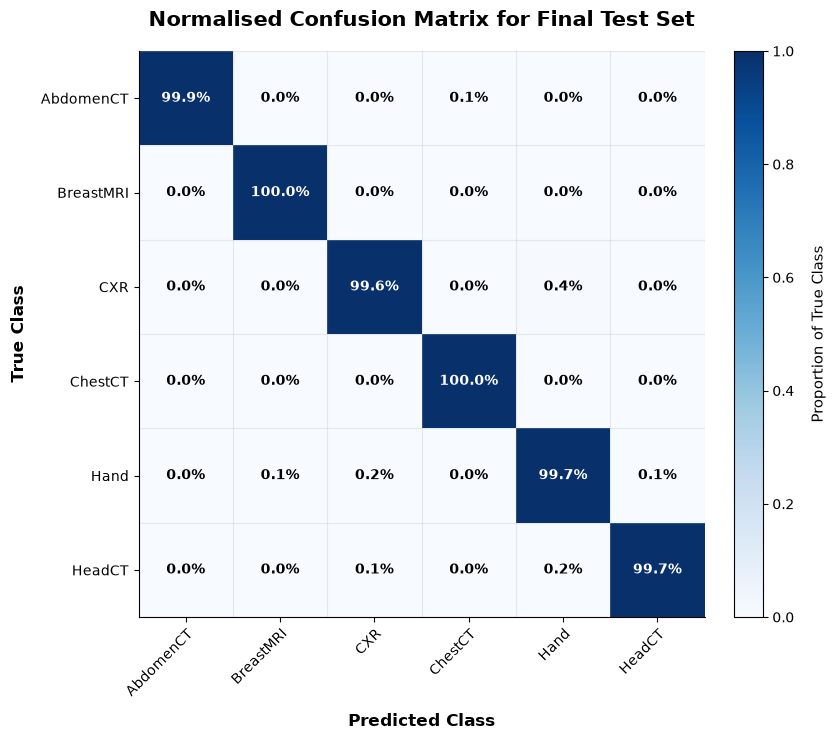

In [38]:
#-------------------- Confusion Matrix ----------------------------------
test_confusion_matrix = confusion_matrix(
    y_test,
    test_predictions,
    normalize="true"
)

#Visualisation 
fig, ax = plt.subplots(figsize=(9, 7.5))

display = ax.imshow(
    test_confusion_matrix,
    cmap="Blues",
    vmin=0,
    vmax=1,
    interpolation="nearest"
)

cbar = fig.colorbar(
    display,
    ax=ax,
    fraction=0.046,
    pad=0.04
)
cbar.set_label(
    "Proportion of True Class",
    fontsize=11,
    labelpad=12
)
cbar.ax.tick_params(labelsize=10)


ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))

ax.set_xticklabels(
    class_names,
    rotation=45,
    ha="right",
    rotation_mode="anchor",
    fontsize=10
)

ax.set_yticklabels(
    class_names,
    fontsize=10
)

ax.set_xlabel(
    "Predicted Class",
    fontsize=12,
    fontweight="bold",
    labelpad=10
)

ax.set_ylabel(
    "True Class",
    fontsize=12,
    fontweight="bold",
    labelpad=10
)

ax.set_title(
    "Normalised Confusion Matrix for Final Test Set",
    fontsize=15,
    fontweight="bold",
    pad=18
)


threshold = test_confusion_matrix.max() / 2

for i in range(len(class_names)):
    for j in range(len(class_names)):

        value = test_confusion_matrix[i, j]

        ax.text(
            j,
            i,
            f"{value:.1%}",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="white" if value > threshold else "black"
        )


ax.set_xticks(
    np.arange(-0.5, len(class_names), 1),
    minor=True
)

ax.set_yticks(
    np.arange(-0.5, len(class_names), 1),
    minor=True
)

ax.grid(
    which="minor",
    linewidth=0.8,
    alpha=0.25
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

plt.show()


#### 7.3 Uncertainty Analysis
Point estimates such as test accuracy provide a single summary of model performance but do not indicate the uncertainty associated with that estimate. Bootstrap resampling is therefore used to calculate approximate 95% confidence intervals for accuracy, balanced accuracy and macro F1-score.

The model is not retrained during this process. Instead, repeated samples are drawn with replacement from the fixed test predictions and true labels. This provides an indication of how much the reported performance metrics might vary due to the composition of the test sample.

In [40]:
#------------------------ Uncertainty Analysis ------------------------------
#Bootstrap resampling of the test set to estimate uncertainty 
rng = np.random.default_rng(SEED)
n_bootstrap = 1000

bootstrap_accuracy = []
bootstrap_balanced_accuracy = []
bootstrap_macro_f1 = []

for _ in range(n_bootstrap):
    # Resample the test set with replacement while keeping
    # the true labels and predictions matched by index
    sample_indices = rng.choice(
        len(y_test),
        size=len(y_test),
        replace=True
    )

    y_true_sample = y_test[sample_indices]
    y_pred_sample = test_predictions[sample_indices]

    bootstrap_accuracy.append(
        accuracy_score(y_true_sample, y_pred_sample)
    )

    bootstrap_balanced_accuracy.append(
        balanced_accuracy_score(y_true_sample, y_pred_sample)
    )

    bootstrap_macro_f1.append(
        f1_score(
            y_true_sample,
            y_pred_sample,
            average="macro",
            zero_division=0
        )
    )

print(f"Bootstrap resamples completed: {n_bootstrap}")

def confidence_interval(values):
    """Compute a 95% percentile-based bootstrap confidence interval"""
    lower = np.percentile(values, 2.5)
    upper = np.percentile(values, 97.5)
    return lower, upper


test_balanced_accuracy = balanced_accuracy_score(
    y_test,
    test_predictions
)

test_macro_f1 = f1_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

accuracy_ci = confidence_interval(
    bootstrap_accuracy
)

balanced_accuracy_ci = confidence_interval(
    bootstrap_balanced_accuracy
)

macro_f1_ci = confidence_interval(
    bootstrap_macro_f1
)

print("Approximate 95% Bootstrap Confidence Intervals")
print("----------------------------------------------")

print(
    f"Accuracy: {test_accuracy:.4f} "
    f"({accuracy_ci[0]:.4f}, {accuracy_ci[1]:.4f})"
)

print(
    f"Balanced Accuracy: {test_balanced_accuracy:.4f} "
    f"({balanced_accuracy_ci[0]:.4f}, "
    f"{balanced_accuracy_ci[1]:.4f})"
)

print(
    f"Macro F1: {test_macro_f1:.4f} "
    f"({macro_f1_ci[0]:.4f}, {macro_f1_ci[1]:.4f})"
)


Bootstrap resamples completed: 1000
Approximate 95% Bootstrap Confidence Intervals
----------------------------------------------
Accuracy: 0.9981 (0.9970, 0.9989)
Balanced Accuracy: 0.9981 (0.9971, 0.9989)
Macro F1: 0.9981 (0.9971, 0.9989)


#### 7.4 Interpretation of Final Test Performance
The final model achieved a test accuracy of 0.9981 (99.81%), a balanced accuracy of 0.9981, and a macro F1-score of 0.9981 on the previously unseen test partition. The test loss was 0.0115. Of the 8,778 test images, only 17 were classified incorrectly.
The close agreement between accuracy, balanced accuracy and macro F1-score indicates that the high overall performance is not being driven by one or two dominant classes. Instead, the model performs consistently across all six medical image categories.
Class-level results support this conclusion. Precision, recall and F1-score exceeded 0.99 for every class. BreastMRI and ChestCT achieved recall values of 1.0000, indicating that all test examples from these classes were correctly identified. The lowest precision was observed for Hand at approximately 0.9940, while the lowest recall was observed for CXR at 0.9960. These differences are small and do not indicate substantial weakness for any individual category.
The bootstrap uncertainty analysis further supports the stability of the observed results. The approximate 95% confidence interval for accuracy was 0.9970 to 0.9989, while balanced accuracy and macro F1 both produced intervals of approximately 0.9971 to 0.9989. The narrow intervals indicate relatively low sampling uncertainty within the available test dataset.
The final model selected its lowest validation-loss state at epoch 4, suggesting that the classification task was learned rapidly and that extended training was unnecessary for the selected architecture.
Although the final results demonstrate very strong generalisation to the reserved test images, they should not be interpreted as evidence of clinical readiness. Exact duplicate images were removed before the final data split, but patient or scan identifiers were unavailable. It is therefore not possible to verify whether related images from the same patient or imaging study occur across different partitions. The results should consequently be interpreted as strong performance on this dataset rather than evidence of generalisation to independent clinical populations.

### 8. Discussion, Limitations and Conclusion
This study applied the universal deep learning workflow to a six-class medical image classification problem using neural networks restricted to Dense and Dropout layers. The investigation progressed from a simple majority-class baseline through controlled experiments examining model capacity, network depth and dropout regularisation, before evaluating the selected model on a previously unseen test partition.
The majority-class baseline achieved only 17.09% accuracy, 16.67% balanced accuracy, and a 0.0487 macro F1-score on the cleaned validation data. This established a clear minimum reference point and demonstrated that high performance would require the model to distinguish meaningfully between all six image categories rather than simply favouring the most frequent class.
The subsequent experiments showed that neural-network capacity had a noticeable effect on performance. The smallest 8 → 4 architecture achieved approximately 98% validation accuracy, while progressively larger networks produced stronger results. However, performance improvements became very small once the network reached moderate capacity. Although the 128 → 64 architecture achieved the strongest numerical result in the capacity experiment, its advantage over the 64 → 32 architecture was negligible. The smaller 64 → 32 configuration was therefore preferred because it provided essentially equivalent predictive performance with lower model complexity.
The network-depth experiment further demonstrated that additional complexity did not necessarily improve generalisation. The two-hidden-layer architecture produced the strongest overall validation results, whereas adding third and fourth hidden layers resulted in slightly weaker performance. Similarly, dropout regularisation did not improve the model. Increasing dropout from 0.0 to 0.5 progressively reduced validation performance, indicating that regularisation was unnecessary for a model that already showed little evidence of substantial overfitting.
Overall, the experiments demonstrate that increasing neural-network complexity beyond an appropriate level does not automatically improve predictive performance. For this dataset, a relatively compact two-hidden-layer Dense network provided sufficient representational capacity for the classification task.

#### 8.1 Limitations
Several limitations should be considered when interpreting the results.
First, an integrity investigation identified 440 duplicate image instances** within the original dataset. Eighty-five validation images in the preliminary split were exact duplicates of images present in the training partition. These duplicates were removed and all data partitions were reconstructed before the systematic experiments and final evaluation. Although this correction reduced the risk of exact duplicate leakage, the dataset does not provide patient or imaging-study identifiers. It was therefore not possible to determine whether different images originating from the same patient or scan were distributed across the training, validation and test partitions.
Second, the six target classes represent visually distinct anatomical regions and imaging modalities. Consequently, the classification problem may be easier than medical tasks involving subtle differences between disease states within the same anatomical region or imaging modality. The very high test performance should therefore be interpreted specifically in relation to the classification task investigated in this study.
Third, the assignment restricted the models to Dense and Dropout layers. Each 64 × 64 image therefore had to be flattened into 4,096 independent input values. This representation does not explicitly preserve the spatial relationships between neighbouring pixels. Convolutional neural networks would normally be more appropriate for image data because they can learn spatial features directly, but such architectures were outside the permitted scope of this investigation.
Fourth, model performance was evaluated using a single dataset and no independent external dataset was available. The final test results therefore provide evidence of generalisation to held-out observations from the same underlying dataset, but they do not demonstrate performance across different hospitals, scanners, acquisition protocols or patient populations.
Finally, although bootstrap confidence intervals were calculated to quantify sampling uncertainty in the final test metrics, no assessment of probability calibration or clinical decision thresholds was performed. The model should therefore not be interpreted as suitable for clinical deployment or diagnostic decision-making.

#### 8.2 Conclusion
The final selected model consisted of two hidden Dense layers containing 64 and 32 neurons, respectively, with ReLU activation and no dropout regularisation. The model was selected exclusively using training and validation evidence, while the cleaned test partition remained untouched until the final evaluation.
On the test set of 8,778 images, the final model achieved an accuracy of 0.9981, balanced accuracy of 0.9981, and macro F1-score of 0.9981, with only 17 images classified incorrectly. Class-level precision, recall and F1-scores exceeded 0.99 for all six categories, indicating that the strong overall performance was not caused by poor performance being hidden within individual classes. Bootstrap analysis produced narrow approximate 95% confidence intervals, with accuracy ranging from 0.9970 to 0.9989.
The investigation therefore demonstrates that a relatively simple fully connected neural network can classify the six medical image categories in this dataset with very high accuracy. More importantly, the systematic experiments showed that larger or deeper models and stronger regularisation did not necessarily improve generalisation. The findings support selecting model complexity according to validation evidence rather than assuming that more complex neural networks will provide superior performance.
Within the limitations of the available dataset and the permitted neural-network architecture, the study successfully demonstrates the main stages of the deep learning workflow: defining the problem, establishing a baseline, preparing and validating the data, systematically experimenting with model design, controlling model selection using validation evidence, and performing a final independent test evaluation.

